#### Name: 

### <font color='purple'> Comments </font> 

<font color='purple'> no name: -2 points </font> 


# PHYS 230 Lab Assignment 14

### Monday, March 30, 2026: Chapter 8.1
- First-order differential equations 

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

### The problem:

Today we will solve a first-order ordinary differential equation for the velocity of a falling ball with air resistance (assuming linear drag). This equation, assuming vertical motion only and downwards as the positive y-direction, is given as: 

$$\frac{dv}{dt}= g -\frac{b}{m}v $$

The exact solution to this differential equation is: 

$$ v(t) = v_0 e^{-\frac{b}{m}t} + v_{\text{ter}} \left( 1 -  e^{-\frac{b}{m}t} \right) $$


where $v_0$ is the initial velocity and $v_{\text{ter}} = \frac{mg}{b}$ is the terminal velocity. For this problem, we will assume that our 1.0 kg ball is initially at rest, so $v_0 = 0$ at $t=0$, the graviational acceleration $g = 9.8 \text{ m/s}^2$, and the drag coefficient $b = 0.1 \frac{\text{N}}{\text{m/s}}$. 

*don't forget comments in your code cells*

### Part 1: Exact Solution

Calculate the exact solution of $v(t)$ for an array of times. Do this in the following steps: 

#### Step 1: 

Write a function `v(t,b,m,v0)` that takes in an array of times (from $t=0$ to $t=100$ by 2's) and constants $b,m,v_0$ and returns an array of velocities using the equation above. Think about any constants might need to be included inside the function. 

In [6]:
def v(t,b,m,v0):
    vter = (m*9.8)/b
    vel = v0*np.exp(-(b/m)*t)+vter*(1-np.exp(-(b/m)*t))
    return vel

### <font color='purple'> Comments </font> 

<font color='purple'> good but you need comments. Waht is this? what is going on?  </font> 


#### Step 2: 

Define the array of times $t$, or whatever variable you want to use, and your necessary constants, and calculate the array of velocities using your function. 

In [7]:
t = np.linspace(0,100,51)
b = 0.1
m = 1.0
v0 = 0.0

vel = v(t,b,m,v0)
print(vel)

[ 0.         17.7643862  32.30863549 44.21645966 53.96576152 61.94781477
 68.48296723 73.83349753 78.21414124 81.80070895 84.73714224 87.14129048
 89.10964058 90.72118933 92.04061386 93.1208673  94.00530401 94.72941954
 95.3222752  95.80766436 96.20506739 96.53043347 96.79682069 97.0149201
 97.19348479 97.33968119 97.45937669 97.55737507 97.63760936 97.70329963
 97.75708229 97.8011158  97.83716739 97.86668393 97.89085004 97.91063557
 97.92683459 97.94009723 97.95095576 97.95984597 97.96712466 97.97308395
 97.977963   97.98195763 97.98522816 97.98790584 97.99009814 97.99189304
 97.99336258 97.99456574 97.99555081]


### <font color='purple'> Comments </font> 

<font color='purple'> good, but `np.arange` might be esaier in this case. Since you know you want to go by steps of 2, `arange` makes it easy for that while `linspace` makes it easy when you know how many points you want</font> 


#### Step 3: 
Make a plot of the results. 

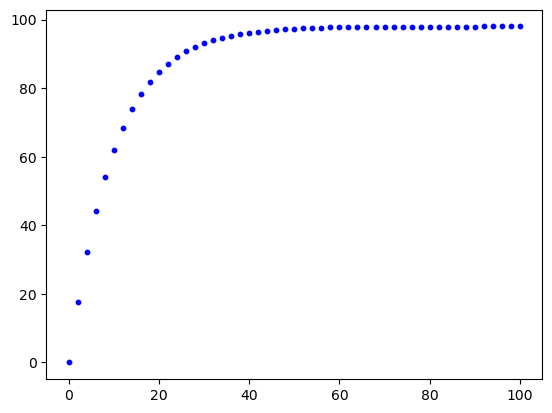

In [8]:
t = np.linspace(0,100,51)
b = 0.1
m = 1.0
v0 = 0.0

vel = v(t,b,m,v0)
plt.scatter(t, vel, color = 'blue', s=10)
plt.show()

### <font color='purple'> Comments </font> 

<font color='purple'>why did you define your constants again? already had those in step 2. should not define the same constants twice with the same names. You also need to label your axes </font> 


### Part 2: Euler Method

Calculate the solution for the same array of times using the Euler method instead. 

#### Step 1: 

Write two functions: `f(v)` that calculate the result of the differential equation for vertical, linear projectile motion, and `euler(t,h,v0,f)` that takes in an array $t$ of times in the same range as part 1 and using a defined $h$ value,initial conditions, and the differential equation returns an *array*. 

In [9]:
def der_v(v):
    return 9.8 - (0.1/1.0)*v
def euler(t,h,v0,f):
    domain = np.zeros(len(t))
    for i in range(len(t)):
        domain[i] = v0
        v0 += h*f(v0)
    return domain

### <font color='purple'> Comments </font> 

<font color='purple'> okay, but shoud use variables, need to leave whitespace (at least 2 lines) between the two functions, and needs comments 

why domain? it doesn't have physical significance to the problem. Are you choosing not to use something with physical significance to make it more generic or did you just choose a random variable name? 

you are also told to use a specific function name. This is done for a specific reason, so you need to follow directions </font> 


#### Step 2

Calculate the array of velocities usig your `euler` function and make a plot of the results with the exact calculation on the **same** graph (put both results on the same graph here).

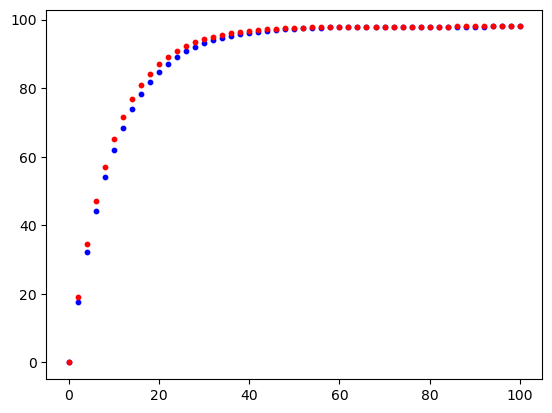

In [10]:
t = np.linspace(0,100,51)
h = (t[-1]-t[0])/len(t)
v0 = 0.0

eul_v = euler(t,h,v0,der_v)
act_v = v(t,0.1,1.0,v0)

plt.scatter(t, act_v, color = 'blue', s=10)
plt.scatter(t, eul_v, color = 'red', s=10)
plt.show()

### <font color='purple'> Comments </font> 

<font color='purple'> need to label axes and include a legend </font> 


### Part 3: Fourth-order Runge-Kutta Method

Calculate the solution for the same array of times using the Runge-Kutta method instead. For this, define a function `RK4(t,h,v0,f)` that takes in an array of times, initial velocity, $h$, initial conditions, and differential equation function. 

Plot this as well as the exact and Euler solutions on the **same** graph as well. 

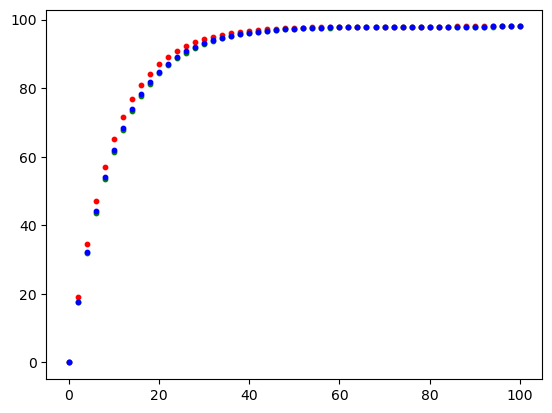

In [11]:
def RK4(t,h,v0,f):
    domain = np.zeros(len(t))
    for i in range(len(t)):
        domain[i] = v0
        k1 = h*f(v0)
        k2 = h*f(v0+0.5*k1)
        k3 = h*f(v0+0.5*k2)
        k4 = h*f(v0+0.5*k3)
        v0 += k4
    return domain

t = np.linspace(0,100,51)
h = (t[-1]-t[0])/len(t)
v0 = 0.0

eul_v = euler(t,h,v0,der_v)
RK_v = RK4(t,h,v0,der_v)
act_v = v(t,0.1,1.0,v0)

plt.scatter(t, eul_v, color = 'red', s=10)
plt.scatter(t, RK_v, color = 'green', s=10)
plt.scatter(t, act_v, color = 'blue', s=10)
plt.show()

### <font color='purple'> Comments </font> 

<font color='purple'> think this looks good, but don't knwo what the colors mean on your graph just looking at it(needs a legend), no axis labels, and your code needs comments for me to truly follow your process. Commenting code is incredibly importanat and at this point in the semester you should be doing it be default </font> 


### Part 4: Markdown comparision

What can you conclude about the results? Do they all agree? (Explain in a markdown cell below - you will need to change it to a markdown cell first)

Euler's method is the less accurate of the two and overestimated. Using the Runge-Kutta Method to the fourth order yielded a much more accurate result, underestimating the value to a lesser degree. In both methods, the error was most noticeable around $0<t<40$, before all estimates became much closer to the actual value due to the slope being near zero at those times.

### <font color='purple'> Comments </font> 

<font color='purple'> nice evalution </font> 


### Part 5: Adjust

Try using smaller and bigger time steps to see the effect of improving your approximations (Euler and/or Runge-Kutta). Explain your results and process in markdown. 

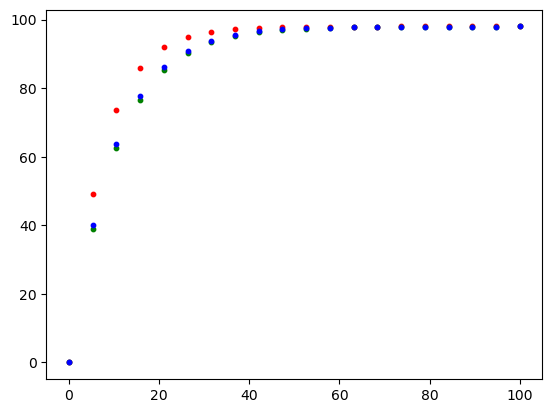

In [46]:
def RK4(t,h,v0,f):
    domain = np.zeros(len(t))
    for i in range(len(t)):
        domain[i] = v0
        k1 = h*f(v0)
        k2 = h*f(v0+0.5*k1)
        k3 = h*f(v0+0.5*k2)
        k4 = h*f(v0+0.5*k3)
        v0 += k4
    return domain

t = np.linspace(0,100,20)
h = (t[-1]-t[0])/len(t)
v0 = 0.0

eul_v = euler(t,h,v0,der_v)
RK_v = RK4(t,h,v0,der_v)
act_v = v(t,0.1,1.0,v0)

plt.scatter(t, eul_v, color = 'red', s=10)
plt.scatter(t, RK_v, color = 'green', s=10)
plt.scatter(t, act_v, color = 'blue', s=10)
plt.show()

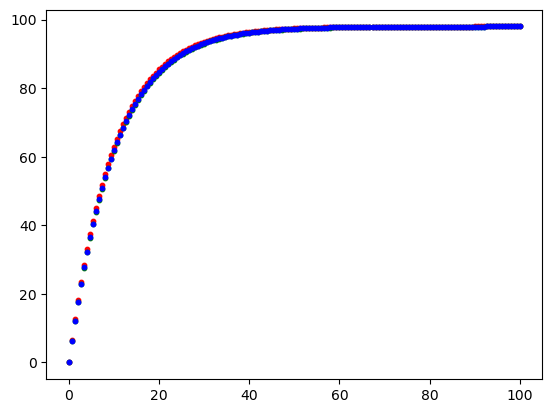

In [47]:
def RK4(t,h,v0,f):
    domain = np.zeros(len(t))
    for i in range(len(t)):
        domain[i] = v0
        k1 = h*f(v0)
        k2 = h*f(v0+0.5*k1)
        k3 = h*f(v0+0.5*k2)
        k4 = h*f(v0+0.5*k3)
        v0 += k4
    return domain

t = np.linspace(0,100,151)
h = (t[-1]-t[0])/len(t)
v0 = 0.0

eul_v = euler(t,h,v0,der_v)
RK_v = RK4(t,h,v0,der_v)
act_v = v(t,0.1,1.0,v0)

plt.scatter(t, eul_v, color = 'red', s=10)
plt.scatter(t, RK_v, color = 'green', s=10)
plt.scatter(t, act_v, color = 'blue', s=10)
plt.show()

#### Explanation Markdown Cell: 

Decreasing the interval between points increased the accuracy of each point, while increasing the interval decreased the accuracy. Since the error of these methods is calculated based on $h$, this is the expected result.

### <font color='purple'> Comments </font> 

<font color='purple'> this should be more detailed. by how much did you increase/decrease - what were your h values? did both methods increase/decrease accuracy?  </font> 
